# PaMIR — a walkthrough

A guided tour of the benchmark: browse the catalog, run a model under both
evaluation protocols, and benchmark a synthetic-data generator.

Everything below runs on a laptop in a few minutes. No GPU, no private repos.

**Setup**

```bash
pip install -e ".[dev,synthetic]"   # `synthetic` adds sdv + xgboost
pytest -q                           # the full test suite, a few minutes
```

Sections 1–2 cover the data, 3–6 the two evaluation protocols, 7 how to read a
fleet result, and 8–9 the synthetic-data side.

In [1]:
# ── Make `pamir` importable ──────────────────────────────────────────────
# This notebook lives in examples/, so the repo root is not on sys.path and a
# bare `import pamir` fails unless the package was installed into the kernel's
# environment.  Walk up from the working directory to the source tree and
# prepend it; a no-op when `pip install -e .` has already been run.
import importlib.util
import sys
from pathlib import Path

if importlib.util.find_spec("pamir") is None:
    for _root in (Path.cwd(), *Path.cwd().parents):
        if (_root / "pamir" / "__init__.py").is_file():
            sys.path.insert(0, str(_root))
            break
    else:
        raise ModuleNotFoundError(
            "pamir not found. Run `pip install -e \".[dev,synthetic]\"` from the "
            "repo root, or start Jupyter from the repo root / examples directory."
        )

# ── Setup ────────────────────────────────────────────────────────────────────
# Import xgboost FIRST.  `sdv` pulls in torch, and on macOS/arm64 loading torch
# before xgboost segfaults the interpreter (duplicate OpenMP runtime).  Harmless
# to keep this line on platforms where the clash doesn't happen.
try:
    import xgboost  # noqa: F401
except ImportError:
    xgboost = None

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pamir

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)

print("pamir", pamir.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
print("xgboost", xgboost.__version__ if xgboost else "not installed")

pamir 0.3.0 | pandas 2.3.3 | numpy 2.3.1
xgboost 3.4.1


In [2]:
# Chart styling used throughout: two categorical hues (blue / orange), recessive
# grid, text in ink tokens rather than series colour.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, MUTED, GRID, SURFACE = "#1a1a19", "#6b6b68", "#e3e3e0", "#fcfcfb"


def style_axes(ax, title, xlabel="", ylabel=""):
    """Apply the shared chart style to one axes object."""
    ax.set_title(title, color=INK, fontsize=12, pad=14, loc="left")
    ax.set_xlabel(xlabel, color=MUTED, fontsize=9)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=9)
    ax.set_facecolor(SURFACE)
    ax.figure.set_facecolor(SURFACE)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)

## 1 · Browse the catalog

`load_catalog()` is the entry point — one row per dataset, indexed by the id you
pass to everything else.

In [3]:
catalog = pamir.load_catalog()

print(f"{len(catalog)} datasets  |  {catalog['rows'].sum():,} rows  |  "
      f"{catalog['defaults'].sum():,} defaults  |  "
      f"default rate {catalog['DR'].min():.1%} – {catalog['DR'].max():.1%}")

catalog[["name", "rows", "features", "DR", "geography", "product", "license"]]

19 datasets  |  1,237,550 rows  |  281,766 defaults  |  default rate 3.2% – 40.9%


,name,rows,features,DR,geography,product,license
id,,,,,,,
bankruptcy,Taiwanese Bankruptcy Prediction,6819,94,0.0323,Taiwan,Corporate,Data files © Original Authors (Kaggle)
bondora,Bondora P2P Lending,266482,46,0.4095,"Estonia, Finland, Spain",P2P consumer,CC0 1.0 (Kaggle reuploader)
conorsully,Conor Sully Credit Score,1000,34,0.2840,Synthetic / educational,Consumer,CC0 1.0
dish,Automobile Loan Default,121856,38,0.0808,Unspecified,Vehicle finance,CC0 1.0 (Kaggle reuploader)
gastonstat,Gaston Sanchez Credit Scoring,4454,13,0.2815,Unknown,Consumer,"No license (GitHub, no LICENSE file)"
gmsc,Give Me Some Credit,150000,10,0.0668,USA,Consumer revolving + installment,Unknown (Kaggle reuploader)
laotse,Laotse Credit Risk,32581,11,0.2182,Unspecified,Consumer,CC0 1.0 (Kaggle reuploader)
lc_clean,"Lending Club (cleaned, 2007–2014)",150000,19,0.2018,USA,P2P consumer,"No license (HuggingFace repo, none stated)"
lc_my,Lending Club (Malaysian variant),100000,16,0.2264,Unspecified,Consumer,Unknown (Kaggle reuploader)


In [4]:
# Provenance for a single dataset.  `notes` records the harmonization applied
# (leakage columns removed, headers rebuilt, values rescaled) — present only on
# the datasets that needed it, so read it with .get().
info = pamir.dataset_info("bondora")
print(info["source_url"])
print(info["target_definition"])
print("\nnotes:", info.get("notes", "— none recorded —"))

print("\nDatasets carrying a provenance note:")
print([d for d in pamir.list_datasets() if pamir.dataset_info(d).get("notes")])

https://www.kaggle.com/datasets/bondora/peer-to-peer-loans
Loan status: defaulted

notes: 23 post-outcome columns removed (PrincipalBalance, LossGivenDefault, etc.)

Datasets carrying a provenance note:
['bondora', 'lc_my', 'pakdd', 'prosper', 'sba']


## 2 · Load a dataset

`load_dataset` returns `(X, y, meta)`. The target is split out of `X` for you,
so there is nothing to drop by hand.

In [5]:
X, y, meta = pamir.load_dataset("taiwan")

print(f"{meta['name']}  |  {meta['n_rows']:,} rows x {meta['n_features']} features  "
      f"|  {meta['n_defaults']:,} defaults ({y.mean():.1%})")
print("dtypes:", dict(X.dtypes.astype(str).value_counts()))

X.head()

Taiwan Credit Card Default  |  30,000 rows x 23 features  |  6,636 defaults (22.1%)
dtypes: {'float64': np.int64(13), 'int64': np.int64(10)}


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,400000.0,1,1,1,34,-2,-2,-2,-2,-2,-2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,80000.0,1,2,2,34,0,0,0,0,0,0,66122.0,92131.0,47655.0,43182.0,44332.0,45440.0,2600.0,4300.0,2000.0,2000.0,2000.0,2000.0
2,200000.0,2,3,1,49,1,-2,-1,-1,-1,-1,0.0,0.0,2317.0,7588.0,7606.0,14053.0,0.0,2317.0,7588.0,7614.0,14053.0,0.0
3,20000.0,2,2,1,41,-1,-1,-1,-1,-1,-1,2468.0,1077.0,1140.0,0.0,7014.0,7696.0,1087.0,1140.0,0.0,7014.0,800.0,0.0
4,70000.0,2,1,1,36,2,0,0,0,0,0,81719.0,85389.0,86287.0,65287.0,35345.0,9360.0,5000.0,3000.0,2000.0,3000.0,5000.0,0.0


## 3 · Write a model

The contract is one function, `predict_fn(X_train, y_train, X_test) -> scores`,
used identically by both protocols. `scores` has one entry per row of `X_test`,
and higher means more likely to default.

`X` arrives with raw dtypes: most of the datasets carry `object` or `bool`
columns. `pamir.encode_features` ordinal-encodes them against a level set shared
between the two frames, so a category maps to the same code in each. Encoding
across train and test together is legal here — the protocol hands you the
features of the rows you must score and withholds only their labels.

If you just want a reference point, `pamir.logistic_baseline` and
`pamir.gbdt_baseline` are the same two models, ready to pass straight to
`evaluate`.

In [6]:
from pamir import encode_features


def logistic(X_train, y_train, X_test):
    from sklearn.impute import SimpleImputer
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    train, test = encode_features(X_train, X_test)
    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=1000),
    )
    model.fit(train, y_train)
    return model.predict_proba(test)[:, 1]


def boosted_trees(X_train, y_train, X_test):
    from sklearn.ensemble import HistGradientBoostingClassifier

    train, test = encode_features(X_train, X_test)
    model = HistGradientBoostingClassifier(max_iter=60, learning_rate=0.1, random_state=42)
    model.fit(train, y_train)
    return model.predict_proba(test)[:, 1]


# Smoke-test the contract before handing either one to the benchmark.
scores = logistic(X.iloc[:5000], y[:5000], X.iloc[5000:6000])
print("scores:", scores.shape, f"range {scores.min():.3f}–{scores.max():.3f}")

scores: (1000,) range 0.001–0.988


## 4 · The streaming protocol

`evaluate_one` replays one dataset as an arriving stream. The model is refitted
every `k_refit` newly resolved defaults, and at each refit it must score the
*entire* remaining stream — predictions are frozen until the next refit.

`refit_points` carries the cumulative AUC at each refit, which is the part worth
plotting: it shows how fast a model becomes useful from a cold start, not just
where it lands.

In [7]:
runs = {}
for label, fn in [("Logistic regression", logistic), ("Boosted trees", boosted_trees)]:
    runs[label] = pamir.evaluate_one(fn, "taiwan", lag=500, k_refit=50, max_n=5000)
    r = runs[label]
    print(f"{label:22s} final AUC {r['auc_final']:.4f}   ({r['n_refits']} refits)")

pd.DataFrame(runs["Boosted trees"]["refit_points"]).head()

Logistic regression    final AUC 0.7202   (21 refits)


Boosted trees          final AUC 0.7457   (21 refits)


,pos,resolved_n,cum_defaults,cum_auc
0,510,10,3,NaN
1,738,238,53,0.500000
2,895,395,103,0.652667
3,1091,591,153,0.655004
4,1331,831,203,0.687359


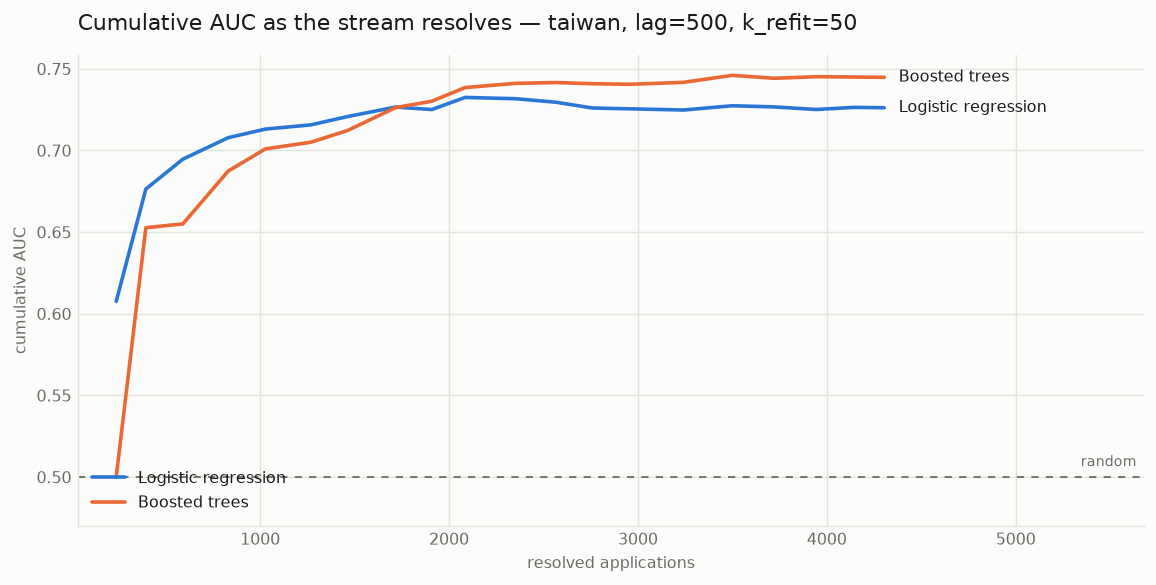

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.6), dpi=130)

for (label, run), colour in zip(runs.items(), (BLUE, ORANGE)):
    points = [p for p in run["refit_points"] if "cum_auc" in p]
    xs = [p["resolved_n"] for p in points]
    ys = [p["cum_auc"] for p in points]
    ax.plot(xs, ys, color=colour, linewidth=2, solid_capstyle="round", label=label)
    ax.annotate(label, (xs[-1], ys[-1]), textcoords="offset points", xytext=(8, 0),
                color=INK, fontsize=9, va="center")

ax.axhline(0.5, color=MUTED, linewidth=1, linestyle=(0, (4, 4)), zorder=1)

style_axes(ax, "Cumulative AUC as the stream resolves — taiwan, lag=500, k_refit=50",
           "resolved applications", "cumulative AUC")
ax.set_xlim(right=ax.get_xlim()[1] * 1.26)
ax.set_ylim(bottom=0.47)
ax.annotate("random", (ax.get_xlim()[1], 0.5), textcoords="offset points",
            xytext=(-4, 6), color=MUTED, fontsize=8, ha="right")
legend = ax.legend(frameon=False, loc="lower left", fontsize=9)
for text in legend.get_texts():
    text.set_color(INK)
plt.tight_layout()
plt.show()

### Choosing `k_refit`

`k_refit` sets how often the model is refitted, and it changes two things.

**The score.** More refits means fresher predictions, so a faster cadence reads
higher. The reference setting is `lag=1000`, `k_refit=10`, `max_n=20000` — the
package defaults. Report all three alongside any number you publish; two runs
are comparable only when they match.

**The cost.** Every refit is a full fit plus a scoring pass over the entire
remaining stream. At `k_refit=10`, `bondora` truncated to 5,000 rows takes 126
refits — roughly 73s with a 60-tree `HistGradientBoosting`, against a default
`max_n` of 20,000 across all 19 datasets. A full fleet run with a tree ensemble
is hours, not minutes; `logistic_baseline` is the cheap reference point.

In [9]:
cadence = []
for k in (10, 40, 100):
    r = pamir.evaluate_one(logistic, "taiwan", lag=500, k_refit=k, max_n=5000)
    cadence.append({"k_refit": k, "n_refits": r["n_refits"],
                    "auc_final": round(r["auc_final"], 4)})

pd.DataFrame(cadence)

,k_refit,n_refits,auc_final
0,10,105,0.7206
1,40,27,0.7192
2,100,11,0.7138


## 5 · Run the fleet

`evaluate` loops the same protocol over a list of datasets. Six datasets here to
keep the notebook quick; drop `datasets=` for all 19.

The frame is flat and exports cleanly — `n_calls` and `n_failures` record how
the model fared, and per-refit detail stays on `evaluate_one`.

In [10]:
FLEET = ["gmsc", "taiwan", "gastonstat", "south_german", "bondora", "prosper"]

streaming = pamir.evaluate(logistic, datasets=FLEET, lag=500, k_refit=40, max_n=5000)
streaming

  gmsc... 

AUC=0.6943 (8 refits)
  taiwan... 

AUC=0.7192 (27 refits)
  gastonstat... 

AUC=0.7660 (28 refits)
  south_german... 

AUC=0.7364 (4 refits)
  bondora... 

AUC=0.6900 (46 refits)
  prosper... 

AUC=0.7364 (35 refits)

  Fleet mean AUC: 0.7237  Gini: 0.447  (6 datasets, all scored)


,dataset,n_rows,n_defaults,DR,n_refits,n_calls,n_failures,auc_final
0,gmsc,5000,328,0.065600,8,8,0,0.694276
1,taiwan,5000,1148,0.229600,27,27,0,0.719221
2,gastonstat,4454,1254,0.281545,28,28,0,0.766023
3,south_german,1000,300,0.300000,4,4,0,0.736410
4,bondora,5000,2036,0.407200,46,46,0,0.690048
5,prosper,5000,1524,0.304800,35,35,0,0.736443


In [11]:
from pamir import fleet_summary

summary = fleet_summary(streaming)
for key in ("n_datasets", "n_scored", "coverage", "complete", "auc_mean", "gini_mean"):
    print(f"{key:12s} {summary[key]}")

n_datasets   6
n_scored     6
coverage     1.0
complete     True
auc_mean     0.7237370066351673
gini_mean    0.44747401327033454


## 6 · The i.i.d. protocol, for comparison

`evaluate_iid` is the conventional shuffled train/test split other tabular
benchmarks use. It is included so PaMIR numbers can be compared with theirs —
the gap between the two columns is the benchmark's whole argument.

In [12]:
iid = pamir.evaluate_iid(logistic, datasets=FLEET, max_n=5000, n_seeds=3)
iid[["dataset", "n_rows", "DR", "auc_mean", "auc_std"]]

  gmsc... 

AUC=0.7037+/-0.0090
  taiwan... 

AUC=0.7301+/-0.0063
  gastonstat... 

AUC=0.7774+/-0.0115
  south_german... 

AUC=0.7788+/-0.0261
  bondora... 

AUC=0.7150+/-0.0072
  prosper... 

AUC=0.7508+/-0.0146

  Fleet mean AUC: 0.7426  Gini: 0.485  (6 datasets, all scored)


,dataset,n_rows,DR,auc_mean,auc_std
0,gmsc,5000,0.065600,0.703708,0.009042
1,taiwan,5000,0.229600,0.730051,0.006345
2,gastonstat,4454,0.281545,0.777386,0.011519
3,south_german,1000,0.300000,0.778832,0.026057
4,bondora,5000,0.407200,0.715005,0.007152
5,prosper,5000,0.304800,0.750826,0.014608


In [13]:
comparison = (
    streaming[["dataset", "auc_final"]]
    .merge(iid[["dataset", "auc_mean"]], on="dataset")
    .rename(columns={"auc_final": "streaming", "auc_mean": "iid"})
    .assign(gap=lambda d: d["iid"] - d["streaming"])
    .sort_values("gap")
    .reset_index(drop=True)
)
print(comparison.to_string(index=False))
print(f"\nmean optimism of the i.i.d. split: {comparison['gap'].mean():+.4f} AUC")

     dataset  streaming      iid      gap
        gmsc   0.694276 0.703708 0.009432
      taiwan   0.719221 0.730051 0.010829
  gastonstat   0.766023 0.777386 0.011363
     prosper   0.736443 0.750826 0.014383
     bondora   0.690048 0.715005 0.024957
south_german   0.736410 0.778832 0.042422

mean optimism of the i.i.d. split: +0.0189 AUC


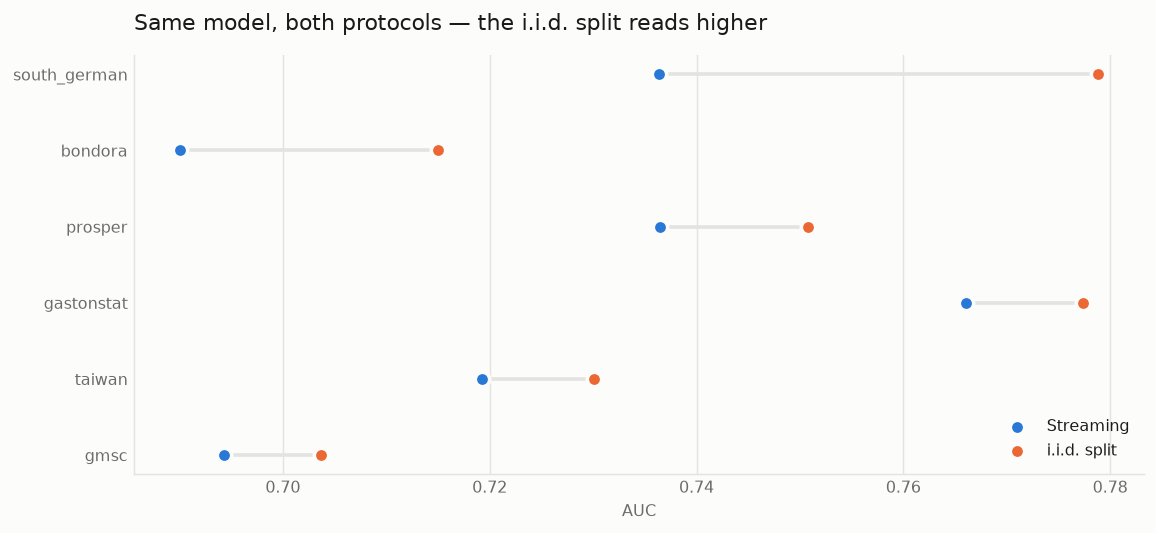

In [14]:
fig, ax = plt.subplots(figsize=(9, 4.2), dpi=130)
rows = np.arange(len(comparison))

for i, row in comparison.iterrows():
    ax.plot([row["streaming"], row["iid"]], [i, i], color=GRID, linewidth=2,
            solid_capstyle="round", zorder=1)
ax.scatter(comparison["streaming"], rows, s=64, color=BLUE, zorder=3,
           edgecolor=SURFACE, linewidth=2, label="Streaming")
ax.scatter(comparison["iid"], rows, s=64, color=ORANGE, zorder=3,
           edgecolor=SURFACE, linewidth=2, label="i.i.d. split")

ax.set_yticks(rows)
ax.set_yticklabels(comparison["dataset"])
style_axes(ax, "Same model, both protocols — the i.i.d. split reads higher", "AUC")
ax.grid(axis="y", visible=False)
legend = ax.legend(frameon=False, loc="lower right", fontsize=9)
for text in legend.get_texts():
    text.set_color(INK)
plt.tight_layout()
plt.show()

## 7 · Coverage: when there is no fleet mean

If your `predict_fn` raises, the affected rows go unscored and that dataset
yields no AUC. Averaging over what is left would report a number your model
selected by failing — a model that crashes on the hard datasets can score
*higher* that way than one that survives all of them.

So `fleet_summary` returns `auc_mean = None` unless every dataset scored. The
partial average is still available as `auc_mean_scored_only`, named so it cannot
be mistaken for a fleet result.

In [15]:
def crashes_on_wide_data(X_train, y_train, X_test):
    """Works on narrow tables, raises on wide ones — a plausible real bug."""
    if X_train.shape[1] > 15:
        raise RuntimeError("some genuine bug in my model")
    return logistic(X_train, y_train, X_test)


broken = pamir.evaluate(crashes_on_wide_data, datasets=FLEET,
                        lag=500, k_refit=40, max_n=5000)
broken[["dataset", "n_refits", "n_calls", "n_failures", "auc_final"]]

  gmsc... 

AUC=0.6943 (8 refits)
  taiwan... 

NO AUC (27 refits, 27/27 calls FAILED)
  gastonstat... 

AUC=0.7660 (28 refits)
  south_german... 

NO AUC (4 refits, 4/4 calls FAILED)
  bondora... 

NO AUC (46 refits, 46/46 calls FAILED)
  prosper... 

NO AUC (35 refits, 35/35 calls FAILED)



  NO FLEET MEAN: 2 of 6 datasets scored (failed: taiwan, south_german, bondora, prosper).
  Mean over the scored subset only: 0.7301 — not comparable with a model that scored the whole fleet.


,dataset,n_refits,n_calls,n_failures,auc_final
0,gmsc,8,8,0,0.694276
1,taiwan,27,27,27,NaN
2,gastonstat,28,28,0,0.766023
3,south_german,4,4,4,NaN
4,bondora,46,46,46,NaN
5,prosper,35,35,35,NaN


In [16]:
working_summary = fleet_summary(streaming)
broken_summary = fleet_summary(broken)

print(f"working model  coverage {working_summary['coverage']:.0%}  "
      f"auc_mean {working_summary['auc_mean']:.4f}")
print(f"broken model   coverage {broken_summary['coverage']:.0%}  "
      f"auc_mean {broken_summary['auc_mean']}")
print(f"\n  failed on: {broken_summary['failed_datasets']}")
print(f"  partial average would have been "
      f"{broken_summary['auc_mean_scored_only']:.4f} — higher than the working "
      "model's, which is exactly why it is not reported as a fleet mean.")

working model  coverage 100%  auc_mean 0.7237
broken model   coverage 33%  auc_mean None

  failed on: ['taiwan', 'south_german', 'bondora', 'prosper']
  partial average would have been 0.7301 — higher than the working model's, which is exactly why it is not reported as a fleet mean.


To find out *why* a model failed, read `errors` off `evaluate_one`, or pass
`on_error="raise"` to get the traceback at the first failure. `"warn"` is the
default and `"ignore"` records failures without warning.

In [17]:
one = pamir.evaluate_one(crashes_on_wide_data, "bondora",
                         lag=500, k_refit=40, max_n=5000)
print(f"{one['n_failures']} of {one['n_calls']} calls failed")
print("errors:", one["errors"])

try:
    pamir.evaluate_one(crashes_on_wide_data, "bondora", lag=500, k_refit=40,
                       max_n=5000, on_error="raise")
except RuntimeError as exc:
    print("\non_error='raise' surfaces it immediately:", exc)

46 of 46 calls failed
errors: ['RuntimeError: some genuine bug in my model']

on_error='raise' surfaces it immediately: some genuine bug in my model


## 8 · Benchmarking a synthetic-data generator

`pamir.synthetic` answers "does training on synthetic rows help?" under a
stratified k-fold protocol that fits the generator *inside* each fold, so no
held-out row ever reaches it.

`SDVAdapter` wraps any SDV synthesizer and needs only the `synthetic` extra.
`ZganAdapter` and `ZedgeAdapter` mix in generators that live in their own repos;
`weights` then splits the synthetic part between them.

In [18]:
from sdv.single_table import GaussianCopulaSynthesizer

from pamir.synthetic import CrossValidatedAugmentation, SDVAdapter, SyntheticMixer

X_sg, y_sg, meta_sg = pamir.load_dataset("south_german")

mixer = SyntheticMixer(
    generators={"copula": SDVAdapter(GaussianCopulaSynthesizer, name="copula")},
    synthetic_share=0.5,   # half the training frame is synthetic
)

result = CrossValidatedAugmentation(mixer, n_splits=3, seed=42).run(
    X_sg, y_sg, dataset="south_german"
)

  fold 0: real=666 synth=666 share=0.50  base=0.7827 aug=0.7683 delta=-0.0144


  fold 1: real=667 synth=667 share=0.50  base=0.8146 aug=0.7591 delta=-0.0555


  fold 2: real=667 synth=667 share=0.50  base=0.7641 aug=0.7099 delta=-0.0542


In [19]:
print(result.summary(), "\n")
result.fold_frame()

dataset            south_german
n_folds                       3
auc_baseline              0.785
auc_augmented             0.745
delta_oof                 -0.04
delta_fold_mean         -0.0414
delta_fold_sd            0.0191
folds_positive                0
dtype: object 



,fold,n_train,n_test,n_real,n_synthetic,realized_share,auc_baseline,auc_augmented,delta
0,0,666,334,666,666,0.5,0.782692,0.768291,-0.014402
1,1,667,333,667,667,0.5,0.814635,0.759142,-0.055494
2,2,667,333,667,667,0.5,0.764120,0.709871,-0.054249


`summary()` is the headline: `auc_baseline` is real rows alone, `auc_augmented`
is the mixed frame, and `delta_oof` is the answer. Negative here — a Gaussian
copula at a 50% share makes this dataset worse, which is the expected result and
a useful check that the harness is not flattering the generator.

Before believing any delta, read the leakage probes.
`synth_holdout_only_overlap` is the one that matters: synthetic rows that
exactly reproduce a held-out row not present in training. Anything above zero
invalidates the delta, however good the rest of the battery looks.

In [20]:
leak = result.leakage_frame()
print(leak.to_string(index=False))

worst = leak["leak.synth_holdout_only_overlap"].max()
print(f"\nworst holdout-only overlap across folds: {worst:.4f}",
      "— clean" if worst == 0 else "— DELTA IS NOT TRUSTWORTHY")

 fold generator  leak.synth_train_exact_overlap  leak.synth_holdout_only_overlap  leak.n_synth_matching_train_only  leak.n_synth_matching_holdout_only
    0    copula                             0.0                              0.0                               0.0                                 0.0
    1    copula                             0.0                              0.0                               0.0                                 0.0
    2    copula                             0.0                              0.0                               0.0                                 0.0

worst holdout-only overlap across folds: 0.0000 — clean


In [21]:
# `fidelity_frame()` returns everything the battery computed — 66 columns on a
# full SDV run.  `fidelity_headline()` is the documented shortlist.
print(f"{result.fidelity_frame().shape[1]} fidelity columns per fold, "
      f"{result.fidelity_headline().shape[1]} on the shortlist\n")

result.fidelity_headline().round(4)

66 fidelity columns per fold, 9 on the shortlist



,fold,generator,leak.synth_holdout_only_overlap,quality_score,table.C2ST_AUC,table.NewRowSynthesis,table.dcr_p05,target_rate_delta,n_errors
0,0,copula,0.0,0.9099,0.8623,NaN,2.3034,0.0210,1.0
1,1,copula,0.0,0.9107,0.8404,NaN,2.1922,0.0270,1.0
2,2,copula,0.0,0.9245,0.8398,NaN,2.2209,-0.0255,1.0


### Does the mix ratio matter?

`synthetic_share` is the knob to sweep first. Two points here for runtime; a real
study would sweep more, and across several datasets.

In [22]:
sweep = []
for share in (0.25, 0.5):
    m = SyntheticMixer(
        generators={"copula": SDVAdapter(GaussianCopulaSynthesizer, name="copula")},
        synthetic_share=share,
    )
    r = CrossValidatedAugmentation(m, n_splits=3, seed=42, verbose=False).run(
        X_sg, y_sg, dataset="south_german"
    )
    s = r.summary()
    sweep.append({
        "synthetic_share": share,
        "auc_baseline": round(float(s["auc_baseline"]), 4),
        "auc_augmented": round(float(s["auc_augmented"]), 4),
        "delta_oof": round(float(s["delta_oof"]), 4),
        "folds_positive": int(s["folds_positive"]),
    })

pd.DataFrame(sweep)

,synthetic_share,auc_baseline,auc_augmented,delta_oof,folds_positive
0,0.25,0.785,0.7675,-0.0174,0
1,0.50,0.785,0.7450,-0.0400,0


## Where to go next

- **Run the real thing.** Drop `datasets=` and `max_n=` to evaluate on the full
  fleet at the reference setting (`lag=1000`, `k_refit=10`, `max_n=20000`).
  Budget hours for a tree ensemble.
- **Report coverage.** Quote `fleet_summary(results)["auc_mean"]`, and state
  `lag`, `k_refit` and `max_n` with it.
- **`docs/protocol.md`** — the exact streaming rules and what a model may not do.
- **`docs/synthetic.md`** — mixing several generators, offline pools, and the
  full fidelity battery.